# What are the most in-demand skills for the top 3 most popular data roles?

## Methodolog

1. Clean up the skill column.
2. Calculate skill count based on `job_title_short`
3. Calculate skill pecentage
4. Plot final findings

In [ ]:
#Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns

#Loading Dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

In [65]:
df_skills = df[df['job_country'] == 'United States'].copy()

df_skills_count = df_skills.explode('job_skills')
df_skills_count = df_skills_count.groupby(['job_skills','job_title_short']).size()

type(df_skills_count) #is a series, we want dataframe

pandas.Series

In [66]:
df_skills_count = df_skills_count.reset_index(name='skill_count')

In [67]:
df_skills_count.sort_values('skill_count', ascending=False, inplace=True)
df_skills_count

,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
1785,vue.js,Business Analyst,1
60,arch,Business Analyst,1
71,asana,Machine Learning Engineer,1
968,no-sql,Machine Learning Engineer,1


## Filtering out all job titles not in the 3 we are looking for (DA,DS,DE)

In [68]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])

job_titles


['Data Analyst', 'Data Engineer', 'Data Scientist']

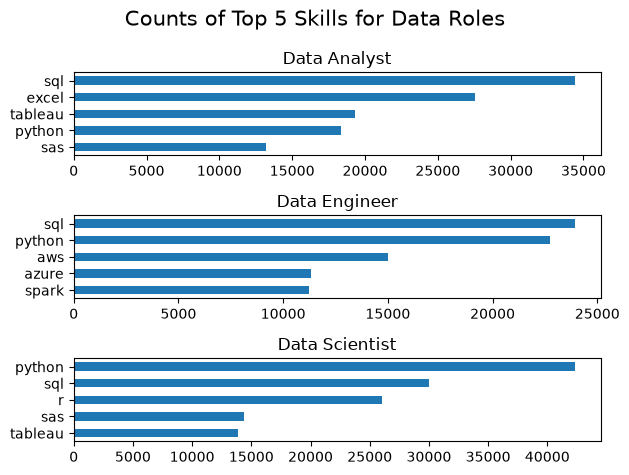

In [69]:
fig, ax = plt.subplots(len(job_titles),1)

for i,title in enumerate(job_titles):
        df_plot = df_skills_count[df_skills_count['job_title_short']==title].head(5)
        df_plot.plot(kind="barh", x='job_skills', y='skill_count', ax=ax[i], title=title)
        ax[i].invert_yaxis()
        ax[i].set_ylabel('')
        ax[i].legend().set_visible(False)
fig.suptitle('Counts of Top 5 Skills for Data Roles', fontsize=15)
plt.tight_layout()
plt.show()

In [70]:

jobs_skills_total = df_skills['job_title_short'].value_counts().reset_index(name='jobs_total')

jobs_skills_total

,job_title_short,jobs_total
0,Data Analyst,67816
1,Data Scientist,58830
2,Data Engineer,35080
3,Senior Data Scientist,12946
4,Senior Data Analyst,11791
5,Senior Data Engineer,9289
6,Business Analyst,7382
7,Software Engineer,1814
8,Machine Learning Engineer,921
9,Cloud Engineer,423


## In order to calculate the percentage of each skill, we need to merge `df_skills_count` with `jobs_skills_total` on `job_title_short`

In [71]:
df_skills_perc = pd.merge(df_skills_count,jobs_skills_total, how='left', on='job_title_short')

df_skills_perc['skill_percent']=100*df_skills_perc['skill_count']/df_skills_perc['jobs_total']

df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,7382,0.013546
1866,arch,Business Analyst,1,7382,0.013546
1867,asana,Machine Learning Engineer,1,921,0.108578
1868,no-sql,Machine Learning Engineer,1,921,0.108578


In [77]:
import seaborn as sns

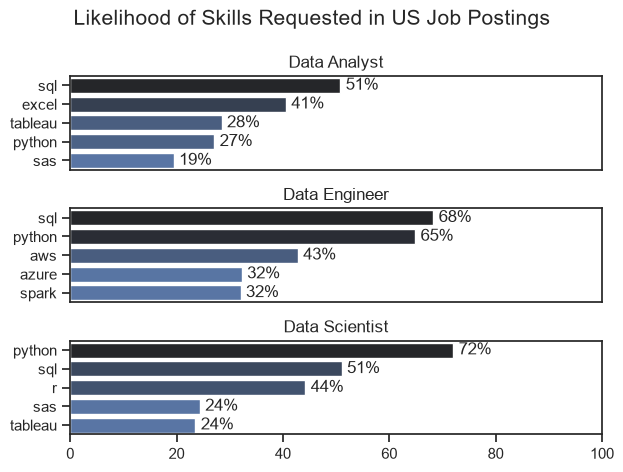

In [98]:
fig, ax = plt.subplots(len(job_titles),1)

sns.set_theme(style='ticks')
for i,title in enumerate(job_titles):
        df_plot = df_skills_perc[df_skills_perc['job_title_short']==title].head(5)
        #df_plot.plot(kind="barh", x='job_skills', y='skill_percent', ax=ax[i], title=title)
        sns.barplot(data=df_plot, x='skill_percent',y='job_skills',ax=ax[i],hue='skill_count',palette='dark:b_r')
#        ax[i].invert_yaxis()
        ax[i].set_title(title)
        ax[i].set_ylabel('')
        ax[i].set_xlabel('')
        ax[i].legend().set_visible(False)
        ax[i].set_xlim(0,100)
        if i != len(job_titles)-1:
                ax[i].set_xticks([])

        for n,v in enumerate(df_plot['skill_percent']):
                ax[i].text(v+1,n,f'{v:.0f}%',va='center')
fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=15)
plt.tight_layout()
plt.show()